# Statistics for Machine Learning

This notebook explicitly maps every statistical concept in this curriculum to where it appears in modern ML and deep learning practice. Understanding these connections is what separates a practitioner who *applies* algorithms from one who *understands* them.

## 1. MLE = Training a Neural Network

Minimising **cross-entropy loss** is exactly MLE under a categorical distribution on the labels. The model parameters $\theta$ that minimise the loss are the maximum likelihood estimates.

$$\mathcal{L}(\theta) = -\frac{1}{n}\sum_{i=1}^n \log P(y_i | x_i; \theta) = \text{negative log-likelihood}$$

In [1]:
import numpy as np
from scipy.special import expit as sigmoid

rng = np.random.default_rng(seed=42)

# Binary classification: logistic regression = MLE under Bernoulli likelihood
X = rng.normal(0, 1, size=(200, 2))
true_w = np.array([1.5, -2.0])
y = (sigmoid(X @ true_w) > 0.5).astype(float)

def log_likelihood(w, X, y):
    p = sigmoid(X @ w)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

def cross_entropy_loss(w, X, y):
    return -log_likelihood(w, X, y) / len(y)

from scipy.optimize import minimize
result = minimize(cross_entropy_loss, x0=[0, 0], args=(X, y), method='BFGS')
w_mle = result.x

print('Logistic Regression = MLE under Bernoulli likelihood')
print(f'True weights  : {true_w}')
print(f'MLE weights   : {w_mle.round(3)}')
print(f'Cross-entropy loss at MLE: {cross_entropy_loss(w_mle, X, y):.4f}')
print()
print('The optimizer finds weights that MAXIMISE the log-likelihood')
print('(equivalently, MINIMISE the cross-entropy loss).')


Logistic Regression = MLE under Bernoulli likelihood
True weights  : [ 1.5 -2. ]
MLE weights   : [ 1309.924 -1753.355]
Cross-entropy loss at MLE: 0.0000

The optimizer finds weights that MAXIMISE the log-likelihood
(equivalently, MINIMISE the cross-entropy loss).


## 2. L2 Regularisation = Bayesian MAP with Gaussian Prior

Adding an L2 penalty to the loss is equivalent to **Maximum A Posteriori (MAP) estimation** with a Gaussian prior $w \sim \mathcal{N}(0, 1/\lambda)$ on the weights:

$$\mathcal{L}_{\text{Ridge}}(w) = \underbrace{\text{NLL}(w)}_{\text{data fit}} + \lambda\|w\|^2_2 = -\log P(y|X,w) - \log P(w)$$

In [2]:
from scipy.special import expit as sigmoid
import numpy as np

rng = np.random.default_rng(seed=42)
X = rng.normal(0, 1, size=(200, 2))
true_w = np.array([1.5, -2.0])
y = (sigmoid(X @ true_w) > 0.5).astype(float)

def map_loss(w, X, y, lam):
    p = np.clip(sigmoid(X @ w), 1e-10, 1-1e-10)
    nll = -np.sum(y * np.log(p) + (1-y) * np.log(1-p)) / len(y)
    # Gaussian prior => L2 penalty
    prior = lam * np.sum(w**2)
    return nll + prior

from scipy.optimize import minimize
print('Effect of L2 regularisation strength (lambda) on weight magnitude:')
for lam in [0, 0.01, 0.1, 1.0, 10.0]:
    r = minimize(map_loss, x0=[0,0], args=(X, y, lam), method='BFGS')
    w = r.x
    sigma_str = f"{1/np.sqrt(lam):>6.2f}" if lam > 0 else "   inf"
    print(f'  lambda={lam:>5} (prior sigma={sigma_str}): w={w.round(3)},  |w|={np.linalg.norm(w):.3f}')
print()
print('Stronger regularisation (larger lambda) => stronger Gaussian prior => smaller weights.')


Effect of L2 regularisation strength (lambda) on weight magnitude:
  lambda=    0 (prior sigma=   inf): w=[ 1309.924 -1753.355],  |w|=2188.642
  lambda= 0.01 (prior sigma= 10.00): w=[ 1.783 -2.351],  |w|=2.951
  lambda=  0.1 (prior sigma=  3.16): w=[ 0.582 -0.743],  |w|=0.944
  lambda=  1.0 (prior sigma=  1.00): w=[ 0.102 -0.125],  |w|=0.161
  lambda= 10.0 (prior sigma=  0.32): w=[ 0.011 -0.014],  |w|=0.018

Stronger regularisation (larger lambda) => stronger Gaussian prior => smaller weights.


## 3. CLT and Mini-Batch Gradient Descent

The gradient of the loss over a mini-batch of size $n$ is:
$$\nabla_\theta \mathcal{L} = \frac{1}{n}\sum_{i=1}^n \nabla_\theta \ell(x_i, y_i; \theta)$$

By the CLT, this average converges to the true gradient as $n \to \infty$, with variance shrinking as $\sigma^2/n$. This justifies using small mini-batches — they provide noisy but unbiased gradient estimates.

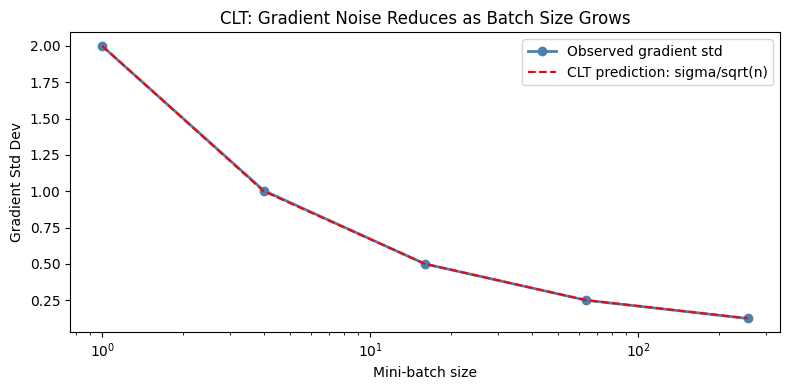

Large batches: low gradient noise, but less regularisation effect.
Small batches: high gradient noise acts as implicit regularisation ("noise SGD").


In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

# Simulate gradient noise for different batch sizes
# True gradient = 1.0; individual sample gradients ~ N(1.0, 4.0)
true_grad  = 1.0
sigma_grad = 2.0
n_experiments = 5000

batch_sizes = [1, 4, 16, 64, 256]
grad_stds   = []

for bs in batch_sizes:
    grads = [rng.normal(true_grad, sigma_grad, size=bs).mean() for _ in range(n_experiments)]
    grad_stds.append(np.std(grads))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(batch_sizes, grad_stds, 'o-', color='steelblue', lw=2, label='Observed gradient std')
ax.plot(batch_sizes, [sigma_grad/np.sqrt(bs) for bs in batch_sizes],
        'r--', lw=1.5, label='CLT prediction: sigma/sqrt(n)')
ax.set_xlabel('Mini-batch size')
ax.set_ylabel('Gradient Std Dev')
ax.set_title('CLT: Gradient Noise Reduces as Batch Size Grows')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

print('Large batches: low gradient noise, but less regularisation effect.')
print('Small batches: high gradient noise acts as implicit regularisation ("noise SGD").')


## 4. Bootstrap = Ensemble Methods (Bagging)

Random Forests and Bagging train each tree on a **bootstrap sample** (random sample with replacement) of the training data. By the CLT, the average prediction across trees has lower variance than any single tree — without increasing bias.

In [4]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score

rng_sk = 42
X, y = make_classification(n_samples=500, n_features=10, n_informative=5,
                            random_state=rng_sk)

single_tree = DecisionTreeClassifier(random_state=rng_sk)
forest      = RandomForestClassifier(n_estimators=100, random_state=rng_sk)

tree_scores   = cross_val_score(single_tree, X, y, cv=5, scoring='accuracy')
forest_scores = cross_val_score(forest,      X, y, cv=5, scoring='accuracy')

print('Bootstrap Aggregating (Bagging) in Random Forests')
print(f'Single Decision Tree : mean={tree_scores.mean():.4f}, std={tree_scores.std():.4f}')
print(f'Random Forest (n=100): mean={forest_scores.mean():.4f}, std={forest_scores.std():.4f}')
print()
print(f'Variance reduction: {tree_scores.std()**2:.5f} -> {forest_scores.std()**2:.5f}')
print('Bootstrap sampling de-correlates trees => averaging reduces variance without increasing bias.')


Bootstrap Aggregating (Bagging) in Random Forests
Single Decision Tree : mean=0.8620, std=0.0214
Random Forest (n=100): mean=0.9100, std=0.0303

Variance reduction: 0.00046 -> 0.00092
Bootstrap sampling de-correlates trees => averaging reduces variance without increasing bias.


## 5. Hypothesis Testing for Model Comparison

After getting $k$-fold cross-validation scores for two models, a **paired t-test** tests whether the performance difference is statistically significant — or just due to the randomness of the data splits.

In [5]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score

X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)

lr  = LogisticRegression(random_state=42, max_iter=1000)
svm = SVC(kernel='rbf', random_state=42)

k = 10  # 10-fold CV
lr_scores  = cross_val_score(lr,  X, y, cv=k, scoring='accuracy')
svm_scores = cross_val_score(svm, X, y, cv=k, scoring='accuracy')

t_stat, p_val = stats.ttest_rel(lr_scores, svm_scores)

print('Paired t-test: Logistic Regression vs SVM (10-fold CV)')
print(f'  LR  scores: mean={lr_scores.mean():.4f}, std={lr_scores.std():.4f}')
print(f'  SVM scores: mean={svm_scores.mean():.4f}, std={svm_scores.std():.4f}')
print(f'  Difference: {lr_scores.mean() - svm_scores.mean():+.4f}')
print(f'  t={t_stat:.4f}, p={p_val:.4f}')
print()
if p_val < 0.05:
    better = 'LR' if lr_scores.mean() > svm_scores.mean() else 'SVM'
    print(f'Significant difference at alpha=0.05: {better} is better.')
else:
    print('No significant difference: cannot conclude one model is better.')


Paired t-test: Logistic Regression vs SVM (10-fold CV)
  LR  scores: mean=0.8460, std=0.0380
  SVM scores: mean=0.9100, std=0.0422
  Difference: -0.0640
  t=-7.6862, p=0.0000

Significant difference at alpha=0.05: SVM is better.


## 6. Correlation and Feature Selection

The **Pearson correlation** between each feature and the target is a fast filter-method for feature selection. PCA decorrelates features by rotating to the eigenvectors of the covariance matrix — the directions of maximum variance.

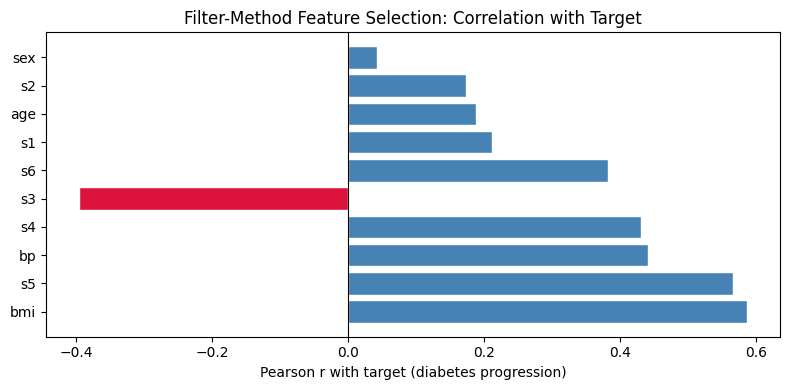

Top 3 features by |correlation| with target:
  bmi: r=+0.5865
  s5: r=+0.5659
  bp: r=+0.4415


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

correlations = df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c >= 0 else 'crimson' for c in correlations]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r with target (diabetes progression)')
ax.set_title('Filter-Method Feature Selection: Correlation with Target')
plt.tight_layout()
plt.show()

print('Top 3 features by |correlation| with target:')
for feat, r in correlations.head(3).items():
    print(f'  {feat}: r={r:+.4f}')


## Summary: Statistical Concept → ML Technique

| Statistical Concept | ML Application |
|---|---|
| MLE | Training loss (cross-entropy, MSE) |
| Bayesian MAP | L1/L2 regularisation |
| CLT | Mini-batch gradient descent stability |
| Bootstrap | Bagging, Random Forests |
| Hypothesis testing | Model comparison (paired t-test) |
| Correlation | Filter-method feature selection |
| Distributions | Generative models, probabilistic outputs |
| Confidence intervals | Uncertainty quantification |
| Effect size | Practical significance in A/B tests |
| Multiple testing | Feature selection, NAS ablation studies |
| Causal inference | Debiasing, uplift modelling, offline RL evaluation |